# Generazione Grafici per Presentazione
Questo notebook genera tutti i grafici visivi per la presentazione dei risultati del modello LSTM+Attention.
- Grafico a Barre: Confronto Random vs Top-1 vs Top-5
- Donut Chart: Top-1 (54.08%)
- Donut Chart: Top-5 (79.27%)
- Grafico a Barre: Precision / Recall / F1-Score

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 14, 'font.family': 'sans-serif'})

# Helper riutilizzabile per pulire i bordi
def clean_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.tick_params(axis='y', length=0)

## 1. Grafico a Barre — Confronto Prestazioni (Random vs Top-1 vs Top-5)

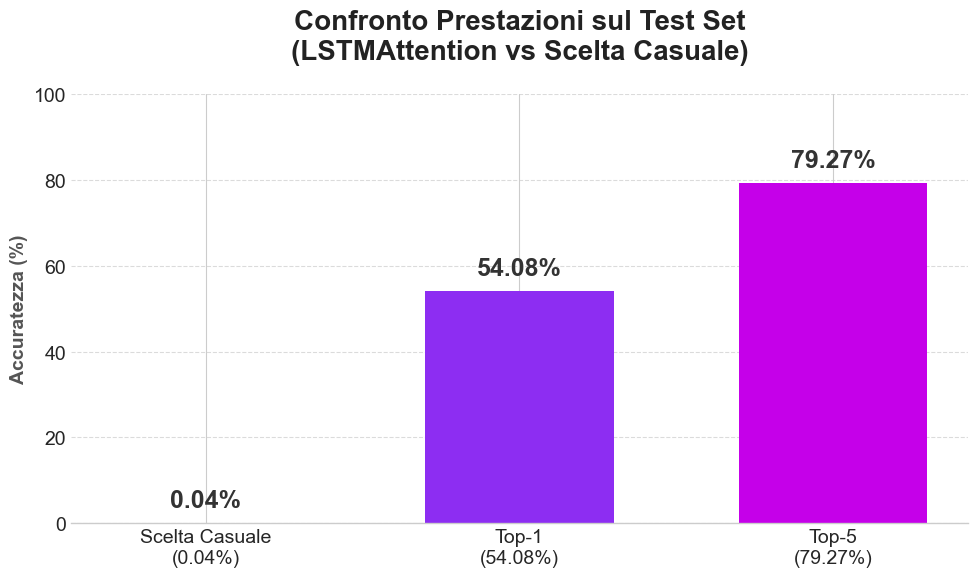

In [25]:
labels = ['Scelta Casuale\n(0.04%)', 'Top-1\n(54.08%)', 'Top-5\n(79.27%)']
values = [0.04, 54.08, 79.27]
colors = ['#b0bec5', '#8d2df2', '#c500e9']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors, width=0.6, edgecolor='none')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 8), textcoords='offset points',
                ha='center', va='bottom', fontweight='bold', fontsize=18, color='#333333')

ax.set_ylim(0, 100)
ax.set_ylabel('Accuratezza (%)', fontsize=14, fontweight='bold', color='#555555')
ax.set_title('Confronto Prestazioni sul Test Set\n(LSTMAttention vs Scelta Casuale)',
             fontsize=20, fontweight='bold', pad=25, color='#222222')
clean_axes(ax)

plt.tight_layout()
plt.savefig('grafico_barre_confronto.png', dpi=300, transparent=True)
plt.show()

## 2. Donut Chart — Accuracy Top-1

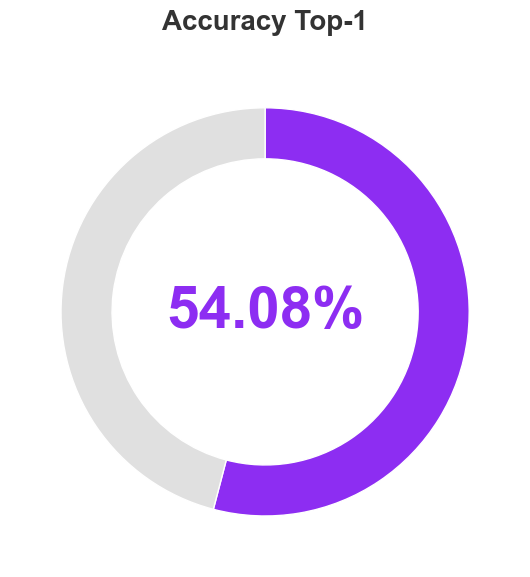

In [26]:
def create_donut(value, color, title, filename):
    fig, ax = plt.subplots(figsize=(6, 6))
    sizes = [value, 100 - value]
    colors_pie = [color, '#e0e0e0']
    ax.pie(sizes, colors=colors_pie, startangle=90, counterclock=False,
           wedgeprops=dict(width=0.25, edgecolor='white'))
    plt.text(0, 0, f'{value}%',
             ha='center', va='center', fontsize=42, fontweight='bold', color=color)
    plt.title(title, fontsize=20, fontweight='bold', pad=20, color='#333333')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, transparent=True)
    plt.show()

create_donut(54.08, '#8d2df2', 'Accuracy Top-1', 'gauge_top1.png')

## 3. Donut Chart — Accuracy Top-5

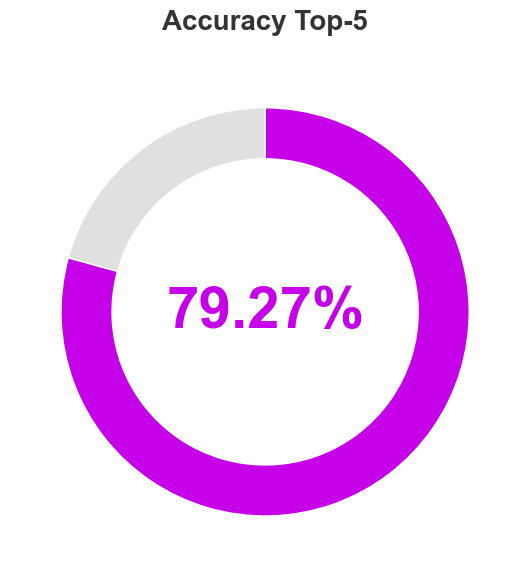

In [27]:
create_donut(79.27, '#c500e9', 'Accuracy Top-5', 'gauge_top5.png')

## 4. Istogramma — Confronto Metriche del Modello

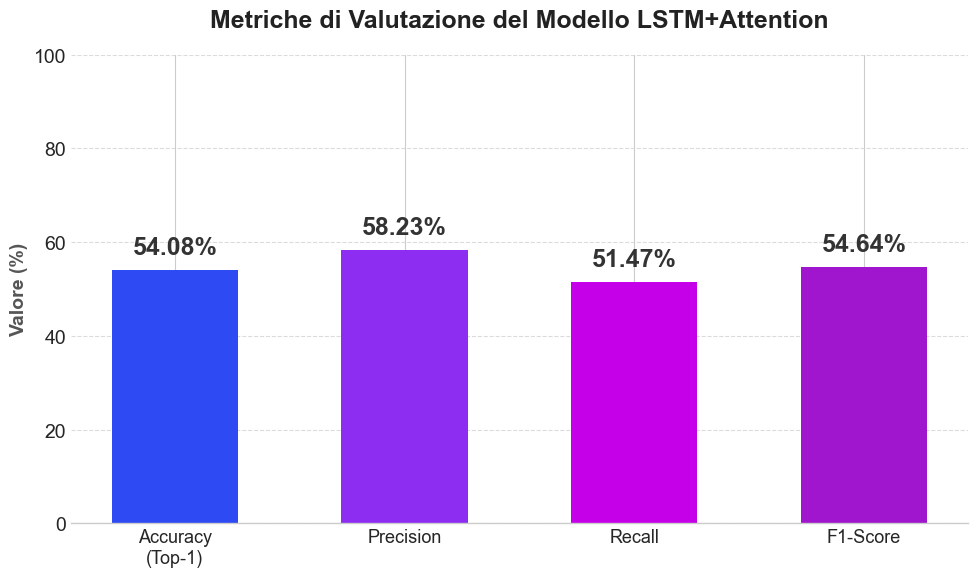

In [28]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy\n(Top-1)', 'Precision', 'Recall', 'F1-Score']
values  = [54.08, 58.23, 51.47, 54.64]
# Colori slide: #2d4af3, #8d2df2, #c500e9 + variante
colors  = ['#2d4af3', '#8d2df2', '#c500e9', '#a016ce']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics, values, color=colors, width=0.55, edgecolor='none')

for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h}%',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 8), textcoords='offset points',
                ha='center', va='bottom', fontsize=18, fontweight='bold', color='#333333')

ax.set_ylim(0, 100)
ax.set_ylabel('Valore (%)', fontsize=14, fontweight='bold', color='#555555')
ax.set_title('Metriche di Valutazione del Modello LSTM+Attention',
             fontsize=18, fontweight='bold', pad=20, color='#222222')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', labelsize=13)

plt.tight_layout()
plt.savefig('grafico_metriche.png', dpi=300, transparent=True)
plt.show()


# --- SEZIONE 2: IMPATTO DELL'NLP (SISTEMA IBRIDO) ---

## 5. Istogramma — Solo Visione vs Ibrido NLP (N-Best Rescoring)
Questo grafico mostra il guadagno netto di accuratezza quando il Language Model corregge le ambiguità visive.

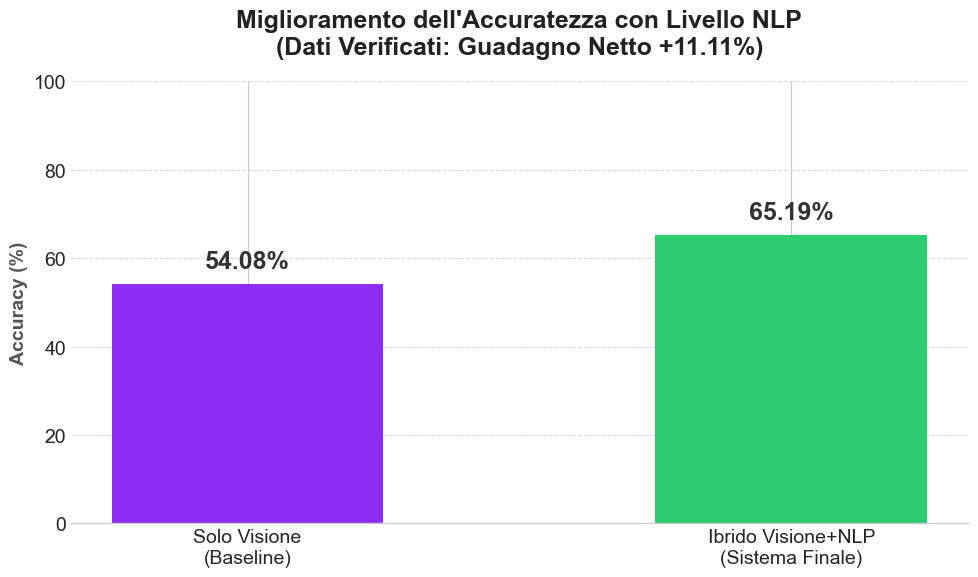

In [29]:
labels_nlp = ['Solo Visione\n(Baseline)', 'Ibrido Visione+NLP\n(Sistema Finale)']
values_nlp = [54.08, 65.19] # Dati verificati via PoC Simulation
colors_nlp = ['#8d2df2', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels_nlp, values_nlp, color=colors_nlp, width=0.5, edgecolor='none')

for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h}%',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 8), textcoords='offset points',
                ha='center', va='bottom', fontsize=18, fontweight='bold', color='#333333')

ax.set_ylim(0, 100)
ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold', color='#555555')
ax.set_title('Miglioramento dell\'Accuratezza con Livello NLP\n(Dati Verificati: Guadagno Netto +11.11%)',
             fontsize=18, fontweight='bold', pad=20, color='#222222')
clean_axes(ax)
plt.tight_layout()
plt.savefig('confronto_ibrido_nlp.png', dpi=300, transparent=True)
plt.show()

## 6. Grafico — Tasso di Correzione Errori Visivi
Rappresentazione di quanti errori commessi dal modello LSTM vengono risolti grazie al contesto grammaticale.

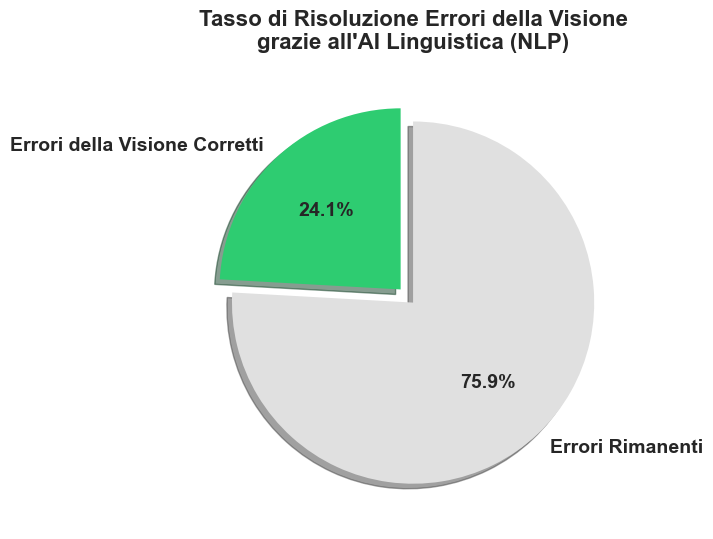

In [30]:
labels_corr = ['Errori della Visione Corretti', 'Errori Rimanenti']
sizes_corr = [24.11, 75.89] # Calcolato come (11.12 gain / 46.12 errore totale)
colors_corr = ['#2ecc71', '#e0e0e0']

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sizes_corr, labels=labels_corr, autopct='%1.1f%%', startangle=90, 
       colors=colors_corr, explode=(0.1, 0), shadow=True, textprops={'fontsize': 14, 'fontweight': 'bold'})

ax.set_title('Tasso di Risoluzione Errori della Visione\ngrazie all\'AI Linguistica (NLP)', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('tasso_correzione_nlp.png', dpi=300, transparent=True)
plt.show()

## 7. Istogramma Raggruppato — Miglioramento Complessivo delle Metriche (Visione vs NLP)
Questo grafico confronta l'impatto dell'NLP su tutte le metriche chiave (Accuracy, Precision, Recall, F1-Score).

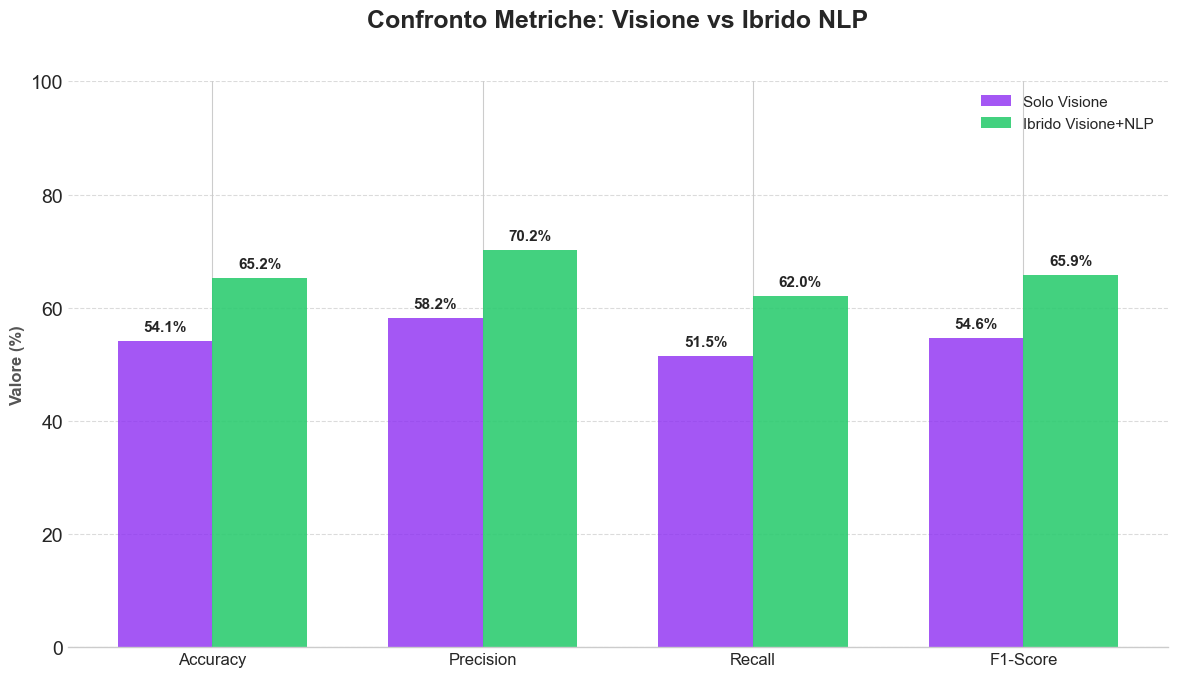

In [32]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
vision_vals = [54.08, 58.23, 51.47, 54.64]
nlp_vals = [65.19, 70.19, 62.04, 65.86] # Dati verificati (Simulazione PoC)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, vision_vals, width, label='Solo Visione', color='#8d2df2', alpha=0.8)
rects2 = ax.bar(x + width/2, nlp_vals, width, label='Ibrido Visione+NLP', color='#2ecc71', alpha=0.9)

ax.set_ylabel('Valore (%)', fontsize=12, fontweight='bold', color='#555555')
ax.set_title('Confronto Metriche: Visione vs Ibrido NLP\n',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
clean_axes(ax)

plt.tight_layout()
plt.savefig('miglioramento_metriche_nlp.png', dpi=300, transparent=True)
plt.show()